# Puntos 2, 3 y 4: Estrategia de análisis, desarrollo y generación de resultados

Este notebook desarrolla los puntos 2, 3 y 4 del Taller 1 de MINE-4101. Parte de los
datos ya tratados en 01_entendimiento_inicial.ipynb, que debe ejecutarse primero para
generar data/secop_bienes_limpio.parquet, y trabaja sobre el periodo de análisis
2020-2024 que se justificó en la sección 6 de ese notebook.

Primero se filtra el periodo y se recalculan las tres señales de desviación. La adición de
plazo se mide sobre todos los contratos del periodo, porque un contrato puede recibir
adiciones mientras está vigente. La no ejecución de presupuesto y el cierre sin liquidar
se miden sobre los contratos cerrados o terminados, porque solo en ellos tiene sentido
preguntar si se pagó o si se liquidó.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)

df_limpio = pd.read_parquet('../data/secop_bienes_limpio.parquet')
print('Dataset limpio completo:', df_limpio.shape)

# Periodo de análisis definido en la sección 6 del notebook 01
df_limpio = df_limpio[df_limpio['en_periodo_analisis']].copy()
print('Contratos en el periodo 2020-2024:', df_limpio.shape)

Dataset limpio completo: (196391, 43)
Contratos en el periodo 2020-2024: (139853, 43)


In [2]:
df_cerrados = df_limpio[
    df_limpio['estado_contrato'].isin(['Cerrado', 'Terminado']) &
    df_limpio['liquidacion_confiable']
].copy()
df_cerrados['no_ejecutado'] = df_cerrados['valor_pagado'] == 0
df_cerrados['sin_liquidar'] = (df_cerrados['liquidaci_n'] == 'No').astype(int)

tasa_adicion_general = (df_limpio['dias_adicionados'] > 0).mean() * 100
tasa_no_ejecutado_general = df_cerrados['no_ejecutado'].mean() * 100
tasa_sin_liquidar_general = df_cerrados['sin_liquidar'].mean() * 100

print('Contratos cerrados o terminados:', len(df_cerrados))
print(f'Adición de plazo, sobre todos los contratos del periodo: {tasa_adicion_general:.2f}%')
print(f'No ejecutado, sobre cerrados o terminados: {tasa_no_ejecutado_general:.2f}%')
print(f'Sin liquidar, sobre cerrados o terminados: {tasa_sin_liquidar_general:.2f}%')
print('Mediana de días adicionados en contratos con adición:',
      df_limpio.loc[df_limpio['dias_adicionados'] > 0, 'dias_adicionados'].median())

Contratos cerrados o terminados: 77928
Adición de plazo, sobre todos los contratos del periodo: 7.90%
No ejecutado, sobre cerrados o terminados: 42.54%
Sin liquidar, sobre cerrados o terminados: 57.40%
Mediana de días adicionados en contratos con adición: 30.0


## 2. Estrategia de análisis

La estrategia parte de las tres señales de desviación que describe el enunciado, medidas
sobre el periodo 2020-2024, el 7.90% de los contratos tuvo adición de plazo, el 42.54% de
los contratos cerrados o terminados no tiene ningún pago registrado, y el 57.40% de los
contratos cerrados o terminados no está liquidado. Estas tres señales son la variable de
salida que se quiere explicar, y la pregunta central es qué características del contrato,
conocidas desde el momento de la firma (su valor, la modalidad de contratación, el sector,
el tipo de entidad y el destino del gasto), se asocian con que un contrato caiga en alguno
de estos grupos de riesgo. Para responder esto se sigue una progresión de menor a mayor
complejidad, empezando por estadísticos descriptivos y proporciones por grupo, siguiendo
con pruebas de hipótesis formales que confirmen si esas diferencias son estadísticamente
significativas o podrían deberse al azar, y cerrando con visualizaciones y cruces que
combinan varios atributos al tiempo, para detectar cuándo dos factores aparentemente
distintos son en realidad el mismo fenómeno.

La elección de la prueba depende del tipo de variable y del número de grupos. Para
variables numéricas como dias_adicionados o valor_del_contrato, que el punto 1 mostró con
distribuciones muy sesgadas y una alta concentración de ceros, se usa Kruskal-Wallis cuando
se comparan más de dos grupos y Mann-Whitney U cuando se comparan dos, ambas sin supuesto
de normalidad. Para las señales binarias, contrato con o sin adición, con o sin pago, con o
sin liquidar, se usa chi cuadrado de independencia contra las variables categóricas,
verificando primero que las frecuencias esperadas sean de al menos 5, y agrupando
categorías cuando no se cumple. En todos los casos se reporta el tamaño del efecto, eta
cuadrado, Cramér's V o correlación rank-biserial, además del valor p, porque con una
muestra de este tamaño casi cualquier diferencia sale significativa. Antes de cada prueba
se define qué diferencia sería lo suficientemente grande como para justificar un cambio en
la supervisión, y cuando se hacen varias pruebas del mismo tipo a la vez se corrige el
nivel de significancia con Bonferroni. Se reportan tanto los resultados significativos
como los que no lo son. Finalmente, cuando dos factores fuertes se solapan, como sector y
modalidad, se estratifica uno dentro del otro antes de recomendarlos como criterios
separados.

## 3. Desarrollo de la estrategia

### 3.1 ¿La modalidad de contratación se asocia con adiciones de plazo más largas?

**Paso 0. Umbral de relevancia práctica.** Antes de probar nada, se define qué
diferencia importaría en la práctica. Una diferencia de al menos 15 días entre
modalidades se considera relevante para la estrategia de supervisión, aproximadamente
la mitad de la mediana de 30 días que tienen los contratos que sí tuvieron adición en
el periodo.

**Paso 1. Hipótesis.**
H0: la distribución de dias_adicionados es la misma en las 9 modalidades de contratación.
H1: al menos una modalidad tiene una distribución distinta, con valores que tienden a ser más altos o más bajos.

In [3]:
resumen_modalidad = df_limpio.groupby('modalidad_de_contratacion')['dias_adicionados'].agg(['count', 'mean', 'median', 'std']).round(2)
print(resumen_modalidad.sort_values('mean', ascending=False))

                                                    count   mean  median  \
modalidad_de_contratacion                                                  
Licitación pública                                   1767  15.64     0.0   
Selección Abreviada Menor Cuantía Sin Manifesta...    186  10.42     0.0   
Contratación régimen especial (con ofertas)          4820   9.97     0.0   
Selección abreviada subasta inversa                 23326   6.56     0.0   
Selección Abreviada de Menor Cuantía                 6224   6.36     0.0   
Contratación Directa (con ofertas)                   4092   4.33     0.0   
Contratación directa                                 3163   3.90     0.0   
Contratación régimen especial                       13699   2.57     0.0   
Mínima cuantía                                      82576   2.33     0.0   

                                                      std  
modalidad_de_contratacion                                  
Licitación pública                         

**Paso 2. Verificación de supuestos.** El punto 1 ya mostró que dias_adicionados tiene
la gran mayoría de sus valores en cero, una distribución completamente alejada de la
normalidad que requiere ANOVA. Por eso, en vez de forzar ANOVA, se usa Kruskal-Wallis,
la alternativa no paramétrica que compara las distribuciones de más de dos grupos sin
asumir normalidad.

**Paso 3. Prueba adecuada y cálculo.**

In [4]:
grupos = [g['dias_adicionados'].dropna().values for _, g in df_limpio.groupby('modalidad_de_contratacion')]
h_stat, p_value = stats.kruskal(*grupos)

print('Kruskal-Wallis: H =', h_stat, ', p =', p_value)

Kruskal-Wallis: H = 2355.910984283587 , p = 0.0


**Paso 4. Tamaño del efecto.**

In [5]:
k = df_limpio['modalidad_de_contratacion'].nunique()
n = df_limpio['dias_adicionados'].notna().sum()
eta_cuadrado = (h_stat - k + 1) / (n - k)
print('Numero de grupos:', k, ', tamano de muestra:', n)
print('Tamaño del efecto (eta cuadrado):', round(eta_cuadrado, 4))

Numero de grupos: 9 , tamano de muestra: 139853
Tamaño del efecto (eta cuadrado): 0.0168


**Paso 5. Comparación puntual entre los dos extremos.** Con 9 modalidades hay 36
comparaciones posibles, pero la más relevante para la estrategia es la de los dos
extremos, Licitación pública, la de mayor promedio, contra Mínima cuantía, la de menor
promedio y la que concentra la mayoría de los contratos. Como las medianas son cero en
ambas, se usa Mann-Whitney U, que no asume normalidad y compara si una distribución
tiende a tener valores más altos que la otra.

In [6]:
licitacion = df_limpio.loc[df_limpio['modalidad_de_contratacion'] == 'Licitación pública', 'dias_adicionados'].dropna()
minima = df_limpio.loc[df_limpio['modalidad_de_contratacion'] == 'Mínima cuantía', 'dias_adicionados'].dropna()

u_stat, p_valor_par = stats.mannwhitneyu(licitacion, minima, alternative='two-sided')

print('Mann-Whitney U (Licitación pública vs Mínima cuantía): U =', u_stat, ', p =', p_valor_par)
print('Diferencia de promedios:', round(licitacion.mean() - minima.mean(), 2), 'días')

Mann-Whitney U (Licitación pública vs Mínima cuantía): U = 86080586.0 , p = 5.880832512780581e-202
Diferencia de promedios: 13.31 días


**Paso 6. Interpretación.**

El tamaño del efecto general (eta cuadrado = 0.0168) es pequeño, la modalidad de
contratación como factor completo explica apenas el 1.7% de la variación en
dias_adicionados. En general, la modalidad no es un buen predictor aislado de cuántos días
se adicionan a un contrato.

La comparación entre los dos extremos es estadísticamente significativa (Mann-Whitney U,
p menor a 0.001), Licitación pública tiene un promedio de 15.64 días adicionados frente a
2.33 en Mínima cuantía. Sin embargo, la diferencia de 13.31 días no alcanza el umbral de
15 días definido en el Paso 0, así que, con el criterio fijado antes de la prueba, no se
considera una diferencia relevante en la práctica. Este es un ejemplo claro de un
resultado estadísticamente significativo que no justifica por sí solo un cambio en la
supervisión.

Como el promedio mezcla dos cosas distintas, cuántos contratos reciben adición y qué tan
larga es, en el siguiente paso se separan.

**Paso 7. Frecuencia de la adición y adición relativa al plazo.** Se prueba si la
proporción de contratos que reciben alguna adición depende de la modalidad, con el mismo
umbral de 10 puntos porcentuales que se usa para las demás proporciones. Además, como
una adición de 30 días no pesa igual en un contrato de un mes que en uno de un año, se
calcula la adición como porcentaje del plazo del contrato, usando duracion_dias
construida en el punto 1.

H0: la proporción de contratos con adición es independiente de la modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [7]:
df_limpio['tuvo_adicion'] = df_limpio['dias_adicionados'] > 0
tabla_adicion = pd.crosstab(df_limpio['modalidad_de_contratacion'], df_limpio['tuvo_adicion'])

chi2_a, p_a, dof_a, esperadas_a = stats.chi2_contingency(tabla_adicion)
cramers_v_a = (chi2_a / (tabla_adicion.values.sum() * (min(tabla_adicion.shape) - 1))) ** 0.5
print(f'Chi2 = {chi2_a:.2f}, p = {p_a}, grados de libertad = {dof_a}')
print(f'Minima frecuencia esperada: {esperadas_a.min():.2f}')
print(f'Cramér V: {cramers_v_a:.4f}')
print()

con_adicion = df_limpio[df_limpio['tuvo_adicion'] & (df_limpio['duracion_dias'] > 0)].copy()
con_adicion['adicion_pct_plazo'] = con_adicion['dias_adicionados'] / con_adicion['duracion_dias'] * 100

resumen_plazo = pd.DataFrame({
    'pct_con_adicion': tabla_adicion[True] / tabla_adicion.sum(axis=1) * 100,
    'duracion_mediana_dias': df_limpio.groupby('modalidad_de_contratacion')['duracion_dias'].median(),
    'mediana_dias_adicionados': con_adicion.groupby('modalidad_de_contratacion')['dias_adicionados'].median(),
    'mediana_adicion_pct_plazo': con_adicion.groupby('modalidad_de_contratacion')['adicion_pct_plazo'].median(),
})
print(resumen_plazo.round(2).sort_values('pct_con_adicion', ascending=False))

Chi2 = 2261.51, p = 0.0, grados de libertad = 8
Minima frecuencia esperada: 14.70
Cramér V: 0.1272

                                                    pct_con_adicion  \
modalidad_de_contratacion                                             
Licitación pública                                            23.71   
Selección Abreviada Menor Cuantía Sin Manifesta...            15.05   
Contratación régimen especial (con ofertas)                   14.77   
Selección Abreviada de Menor Cuantía                          12.50   
Selección abreviada subasta inversa                           12.26   
Contratación Directa (con ofertas)                             7.70   
Contratación directa                                           6.83   
Mínima cuantía                                                 6.13   
Contratación régimen especial                                  4.80   

                                                    duracion_mediana_dias  \
modalidad_de_contratacion                

La proporción de contratos con adición sí depende de la modalidad (chi cuadrado con p
menor a 0.001, frecuencia esperada mínima de 14.70, Cramér's V = 0.1272, efecto pequeño).
Licitación pública se separa claramente, el 23.71% de sus contratos recibió alguna
adición frente a 6.13% en Mínima cuantía, una diferencia de 17.58 puntos que supera el
umbral de 10.

Pero la adición relativa al plazo cuenta otra historia. Los contratos de Licitación
pública son mucho más largos (mediana de 169 días frente a 44 en Mínima cuantía), y cuando
se les adiciona tiempo la adición representa una mediana de 11.65% de su plazo, frente a
33.70% en Mínima cuantía. Es decir, en Licitación pública la adición es más frecuente pero
proporcionalmente más corta, lo cual es esperable en contratos de mayor duración y
complejidad.

En conclusión, la modalidad no es un criterio fuerte para anticipar cuántos días se
adicionan, pero Licitación pública sí es un criterio útil para anticipar que habrá alguna
adición, casi uno de cada cuatro contratos, por lo que su supervisión debería centrarse
en el seguimiento del cronograma más que en la magnitud de la ampliación.

### 3.2 ¿La modalidad de contratación se asocia con presupuesto no ejecutado?

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al
menos 10 puntos porcentuales entre modalidades en la proporción de contratos cerrados
o terminados sin ningún pago registrado.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin ejecutar presupuesto es independiente de la
modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [8]:
tabla_ejecucion = pd.crosstab(df_cerrados['modalidad_de_contratacion'], df_cerrados['no_ejecutado'])
print(tabla_ejecucion)
print()
proporciones = (pd.crosstab(df_cerrados['modalidad_de_contratacion'], df_cerrados['no_ejecutado'], normalize='index') * 100).round(2)
print(proporciones)

no_ejecutado                                        False  True 
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                   1379   1121
Contratación directa                                  694    859
Contratación régimen especial                        2760   4198
Contratación régimen especial (con ofertas)           456   2221
Licitación pública                                    542    372
Mínima cuantía                                      28448  17643
Selección Abreviada Menor Cuantía Sin Manifesta...     75     39
Selección Abreviada de Menor Cuantía                 1953   1680
Selección abreviada subasta inversa                  8474   5014

no_ejecutado                                        False  True 
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                  55.16  44.84
Contratación directa                                44.69  55.31
Contratación régimen esp

**Paso 2 y 3. Supuestos y prueba.** Para chi cuadrado de independencia se requiere que
las frecuencias esperadas sean de al menos 5 en cada celda. Se verifica antes de
interpretar el resultado, y se calcula también Cramér's V como tamaño del efecto, dado
que con un tamaño de muestra tan grande el p valor por sí solo tiende a salir
significativo.

In [9]:
chi2, p_value, dof, esperadas = stats.chi2_contingency(tabla_ejecucion)
print('Chi2 =', chi2, ', p =', p_value, ', grados de libertad =', dof)
print('Minima frecuencia esperada:', esperadas.min())

n = tabla_ejecucion.values.sum()
k_min = min(tabla_ejecucion.shape) - 1
cramers_v = (chi2 / (n * k_min)) ** 0.5
print('Cramér V:', round(cramers_v, 4))

Chi2 = 3326.3910384779897 , p = 0.0 , grados de libertad = 8
Minima frecuencia esperada: 48.49037573144441
Cramér V: 0.2066


**Paso 4. Interpretación.**

El estadístico chi-cuadrado (`chi2` = 3326.39, `p` = 0.0, `df` = 8) muestra una asociación estadísticamente significativa entre `modalidad_de_contratacion` y `no_ejecutado`. El supuesto de frecuencia esperada mínima mayor o igual a 5 se cumple (mínimo de 48.49).

El tamaño del efecto, Cramér's V = 0.2066, es un efecto pequeño a moderado según las convenciones de Cohen para esta tabla (entre 0.10 y 0.30), el más fuerte de las pruebas de modalidad de este punto.

Frente a la tasa general de 42.54%, las modalidades competitivas se agrupan por debajo, `Selección abreviada subasta inversa` 37.17%, `Mínima cuantía` 38.28% y `Licitación pública` 40.70%. En el extremo opuesto, `Contratación régimen especial (con ofertas)` llega a 82.97%, cuarenta puntos por encima de la tasa general, seguida de `Contratación régimen especial` con 60.33% y `Contratación directa` con 55.31%. Las tres superan con holgura el umbral de 10 puntos definido en el Paso 0.

En conclusión, las modalidades de régimen especial, y en menor medida la contratación directa, concentran la mayor proporción de contratos cerrados sin pagos registrados.

**Paso 5. ¿Un pago en cero es falta de ejecución o falta de registro?** La bandera
`no_ejecutado` supone que un contrato cerrado sin pagos registrados en SECOP II no ejecutó
su presupuesto. Pero si una entidad no usa la plataforma para registrar pagos, todos sus
contratos aparecerían como no ejecutados aunque sí se hayan pagado. Para dimensionar este
riesgo se revisa cuántas entidades no registran ningún pago en ninguno de sus contratos
cerrados o terminados.

In [10]:
por_entidad = df_cerrados.groupby('nombre_entidad')['no_ejecutado'].agg(['size', 'mean'])
entidades_5 = por_entidad[por_entidad['size'] >= 5]
entidades_sin_pagos = entidades_5[entidades_5['mean'] == 1].index

print('Entidades con al menos 5 contratos cerrados o terminados:', len(entidades_5))
print('De esas, sin ningún pago registrado en todos sus contratos:', len(entidades_sin_pagos),
      f'({len(entidades_sin_pagos) / len(entidades_5) * 100:.2f}%)')

aporte = (df_cerrados.loc[df_cerrados['nombre_entidad'].isin(entidades_sin_pagos), 'no_ejecutado'].sum()
          / df_cerrados['no_ejecutado'].sum() * 100)
print(f'Porcentaje de los contratos no ejecutados que viene de esas entidades: {aporte:.2f}%')

Entidades con al menos 5 contratos cerrados o terminados: 1479
De esas, sin ningún pago registrado en todos sus contratos: 233 (15.75%)
Porcentaje de los contratos no ejecutados que viene de esas entidades: 20.61%


El 15.75% de las entidades con al menos 5 contratos cerrados o terminados no registra
ningún pago en ninguno de ellos, y esas entidades aportan el 20.61% de todos los contratos
marcados como no ejecutados. Es poco probable que una entidad no haya pagado ni uno solo
de sus contratos, así que en esos casos la señal refleja sobre todo una práctica de
registro, no una falta real de ejecución.

Esto no invalida el hallazgo, pero cambia cómo se debe usar. `no_ejecutado` es una señal de
que el contrato no tiene trazabilidad financiera en SECOP II, lo cual ya es un motivo de
supervisión, y la oficina de control interno debería confirmar con la entidad si el pago
no ocurrió o solo no se registró. Esta salvedad se documenta en las limitaciones del
punto 4.

### 3.3 ¿La modalidad de contratación se asocia con el cierre sin liquidar?

Analizamos la tercera señal de desviación (57.40% de contratos cerrados o terminados sin liquidar en el periodo) contra `modalidad_de_contratacion`, siguiendo la misma lógica de umbral de relevancia práctica, prueba estadística y tamaño del efecto usada en 3.1 y 3.2.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre modalidades.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin liquidar es independiente de la modalidad de contratación.
H1: la proporción depende de la modalidad de contratación.

In [11]:
tabla_counts = pd.crosstab(df_cerrados['modalidad_de_contratacion'], df_cerrados['sin_liquidar'])
tabla_pct = pd.crosstab(df_cerrados['modalidad_de_contratacion'], df_cerrados['sin_liquidar'], normalize='index') * 100

print("Tabla de conteos")
print(tabla_counts)
print()
print("Porcentaje sin_liquidar (columna 1) por modalidad")
print(tabla_pct[1].sort_values(ascending=False))

chi2, p, dof, expected = stats.chi2_contingency(tabla_counts)
print()
print(f"Chi2 = {chi2}, p = {p}, grados de libertad = {dof}")
print(f"Minima frecuencia esperada: {expected.min()}")

n = tabla_counts.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(tabla_counts.shape) - 1)))
print(f"Cramér V: {cramers_v}")

Tabla de conteos
sin_liquidar                                            0      1
modalidad_de_contratacion                                       
Contratación Directa (con ofertas)                   1263   1237
Contratación directa                                  527   1026
Contratación régimen especial                        1937   5021
Contratación régimen especial (con ofertas)           430   2247
Licitación pública                                    493    421
Mínima cuantía                                      19423  26668
Selección Abreviada Menor Cuantía Sin Manifesta...     81     33
Selección Abreviada de Menor Cuantía                 1874   1759
Selección abreviada subasta inversa                  7170   6318

Porcentaje sin_liquidar (columna 1) por modalidad
modalidad_de_contratacion
Contratación régimen especial (con ofertas)                    83.937243
Contratación régimen especial                                  72.161541
Contratación directa                         

**Paso 2. Interpretación.**

El estadístico chi-cuadrado (`chi2` = 2327.42, `p` = 0.0, `df` = 8) muestra una asociación estadísticamente muy significativa entre `modalidad_de_contratacion` y `sin_liquidar`. El supuesto de frecuencia esperada mínima mayor o igual a 5 se cumple (mínimo de 48.56).

El tamaño del efecto, Cramér's V = 0.1728, es un efecto pequeño, por encima del umbral de 0.10 pero lejos del efecto moderado (0.30).

Frente a la tasa general de 57.40%, tres modalidades quedan muy por encima: `Contratación régimen especial (con ofertas)` con 83.94%, `Contratación régimen especial` con 72.16%, y `Contratación directa` con 66.07%. En el extremo opuesto, `Selección Abreviada Menor Cuantía Sin Manifestación Interés` (28.95%, con solo 114 contratos cerrados) y `Licitación pública` (46.06%) quedan por debajo. La diferencia entre el valor máximo y el mínimo es de 54.99 puntos porcentuales, muy por encima del umbral de 10 puntos.

Un hallazgo relevante es que las mismas modalidades que destacan en no ejecución (3.2) son las que destacan aquí, mientras que `Licitación pública`, que se separa en frecuencia de adiciones (3.1), aquí se comporta por debajo del promedio. El riesgo no es uniforme por modalidad, y el criterio de focalización debe reflejar esa diferencia.

### 3.4 Síntesis parcial: modalidad de contratación

- En **adiciones de plazo** (3.1), el efecto global es débil (eta² = 0.0168) y la diferencia en días entre Licitación pública y Mínima cuantía (13.31 días) no alcanza el umbral de 15. Sin embargo, `Licitación pública` es la modalidad con más contratos adicionados (23.71% frente a 6.13% en Mínima cuantía), aunque sus adiciones son cortas en relación con su plazo.

- En **presupuesto no ejecutado** (3.2), el efecto es pequeño a moderado (Cramér's V = 0.2066), con `Contratación régimen especial (con ofertas)` en 82.97% frente a una tasa general de 42.54%.

- En **cierre sin liquidar** (3.3), el efecto es pequeño (Cramér's V = 0.1728), con las dos modalidades de régimen especial y la contratación directa muy por encima del promedio.

Las dos modalidades de régimen especial son las únicas que aparecen como factor de riesgo en dos de las tres señales, lo que las convierte en candidatas a un criterio de focalización transversal. `Licitación pública`, en cambio, es un factor de riesgo específico para la ocurrencia de adiciones de plazo.

### 3.5 Visualización multivariada: síntesis visual del riesgo por modalidad

Aquí construimos una sola visualización que combina las tres señales para identificar qué modalidades concentran riesgo en más de una dimensión a la vez. Cada burbuja es una modalidad, el eje X es el porcentaje de contratos cerrados o terminados sin pagos, el eje Y el porcentaje sin liquidar, el tamaño es el número de contratos y el color la adición de plazo promedio.

                                                    n_contratos  \
modalidad_de_contratacion                                         
Contratación Directa (con ofertas)                         4092   
Contratación directa                                       3163   
Contratación régimen especial                             13699   
Contratación régimen especial (con ofertas)                4820   
Licitación pública                                         1767   
Mínima cuantía                                            82576   
Selección Abreviada Menor Cuantía Sin Manifesta...          186   
Selección Abreviada de Menor Cuantía                       6224   
Selección abreviada subasta inversa                       23326   

                                                    dias_adicionados_promedio  \
modalidad_de_contratacion                                                       
Contratación Directa (con ofertas)                                       4.33   
Contratación direct

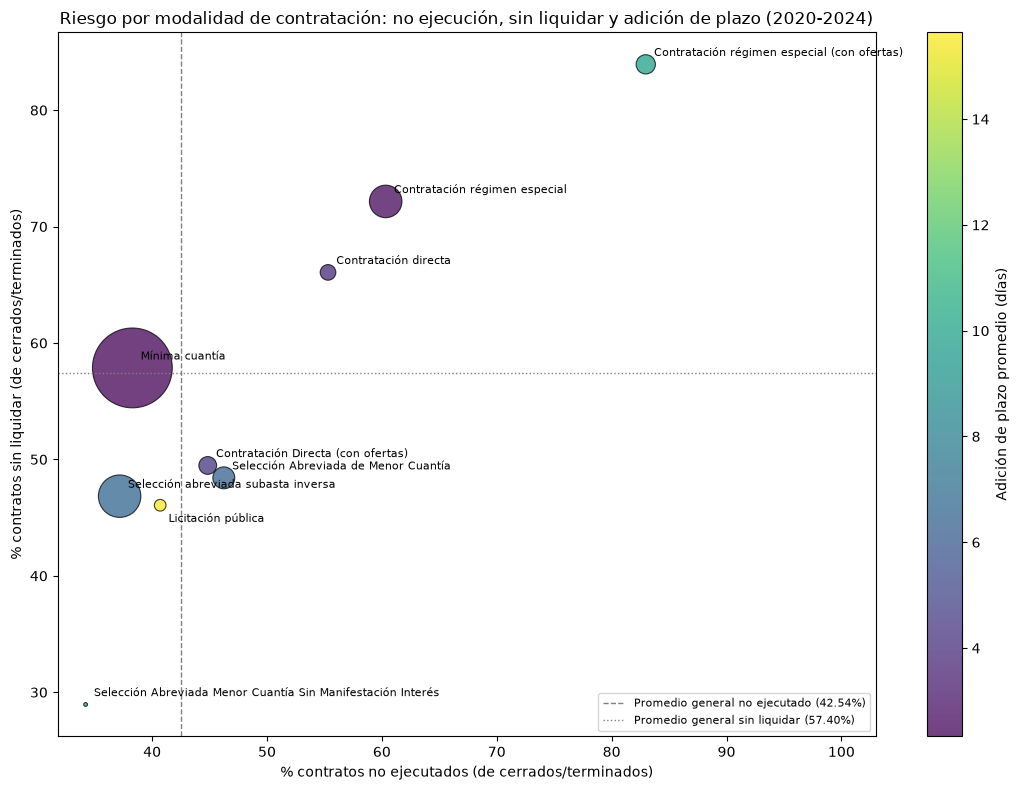

In [12]:
resumen_modalidad = df_limpio.groupby('modalidad_de_contratacion').agg(
    n_contratos=('modalidad_de_contratacion', 'size'),
    dias_adicionados_promedio=('dias_adicionados', 'mean')
)

resumen_modalidad['pct_no_ejecutado'] = proporciones[True]
resumen_modalidad['pct_sin_liquidar'] = tabla_pct[1]

print(resumen_modalidad.round(2))

fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    resumen_modalidad['pct_no_ejecutado'],
    resumen_modalidad['pct_sin_liquidar'],
    s=resumen_modalidad['n_contratos'] / 25,
    c=resumen_modalidad['dias_adicionados_promedio'],
    cmap='viridis',
    alpha=0.75,
    edgecolors='black',
    linewidths=0.8
)

for modalidad, fila in resumen_modalidad.iterrows():
    ax.annotate(
        modalidad,
        (fila['pct_no_ejecutado'], fila['pct_sin_liquidar']),
        fontsize=8,
        xytext=(6, -12 if modalidad == 'Licitación pública' else 6),
        textcoords='offset points'
    )

ax.axvline(tasa_no_ejecutado_general, color='gray', linestyle='--', linewidth=1,
           label=f'Promedio general no ejecutado ({tasa_no_ejecutado_general:.2f}%)')
ax.axhline(tasa_sin_liquidar_general, color='gray', linestyle=':', linewidth=1,
           label=f'Promedio general sin liquidar ({tasa_sin_liquidar_general:.2f}%)')
ax.set_xlim(right=resumen_modalidad['pct_no_ejecutado'].max() + 20)

ax.set_xlabel('% contratos no ejecutados (de cerrados/terminados)')
ax.set_ylabel('% contratos sin liquidar (de cerrados/terminados)')
ax.set_title('Riesgo por modalidad de contratación: no ejecución, sin liquidar y adición de plazo (2020-2024)')
ax.legend(loc='lower right', fontsize=8)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Adición de plazo promedio (días)')

plt.tight_layout()
plt.show()

**Interpretación.**

El gráfico confirma visualmente los hallazgos estadísticos de 3.1 a 3.3. `Contratación régimen especial (con ofertas)` aparece claramente aislada en la esquina superior derecha, con el porcentaje más alto de no ejecución (82.97%) y de cierre sin liquidar (83.94%) de todas las modalidades, y `Contratación régimen especial` y `Contratación directa` también quedan por encima de ambas líneas de referencia.

`Licitación pública` es un caso distinto. Está por debajo del promedio general en no ejecución (40.70% frente a 42.54%) y en sin liquidar (46.06% frente a 57.40%), pero tiene la adición de plazo promedio más alta de todas las modalidades (15.64 días), lo que confirma que su riesgo es específico a la dimensión de plazos.

`Mínima cuantía` concentra el 59% de los contratos del periodo (n=82576) y se ubica cerca de ambas líneas de referencia, algo esperable porque es la modalidad que en buena parte define el promedio general.

`Selección Abreviada Menor Cuantía Sin Manifestación Interés` tiene apenas 186 contratos, la burbuja más pequeña del gráfico. Aunque muestra el porcentaje más bajo en ambas señales, ese resultado se apoya en una muestra pequeña y debería tratarse con cautela.

### 3.6 Visualización complementaria: valor del contrato según modalidad y estado de liquidación

Ninguna de las visualizaciones anteriores incluyó `valor_del_contrato`, a pesar de ser uno de los atributos principales del Punto 1. Aquí comparamos la distribución del valor del contrato por modalidad, separando entre contratos liquidados y sin liquidar, para ver si el riesgo de no liquidación se concentra en los contratos de mayor o de menor valor dentro de cada modalidad.

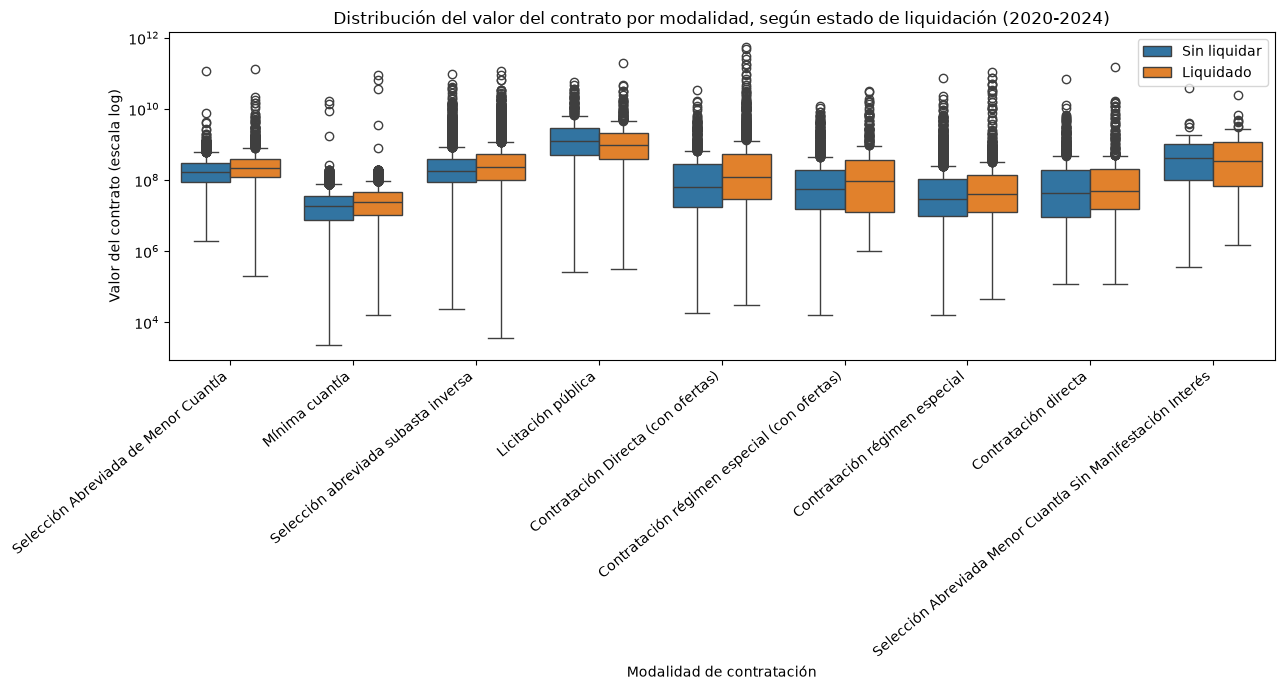

modalidad_de_contratacion                                    sin_liquidar_label
Contratación Directa (con ofertas)                           Liquidado             1.190499e+08
                                                             Sin liquidar          6.570000e+07
Contratación directa                                         Liquidado             4.853827e+07
                                                             Sin liquidar          4.369680e+07
Contratación régimen especial                                Liquidado             4.000000e+07
                                                             Sin liquidar          3.000000e+07
Contratación régimen especial (con ofertas)                  Liquidado             9.369807e+07
                                                             Sin liquidar          5.501496e+07
Licitación pública                                           Liquidado             9.836540e+08
                                                        

In [13]:
datos_valor = df_cerrados[
    df_cerrados['valor_confiable'] &
    (df_cerrados['valor_del_contrato'] > 0)
].copy()

datos_valor['sin_liquidar_label'] = np.where(datos_valor['sin_liquidar'] == 1, 'Sin liquidar', 'Liquidado')

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(
    data=datos_valor,
    x='modalidad_de_contratacion',
    y='valor_del_contrato',
    hue='sin_liquidar_label',
    ax=ax
)
ax.set_yscale('log')
ax.set_xlabel('Modalidad de contratación')
ax.set_ylabel('Valor del contrato (escala log)')
ax.set_title('Distribución del valor del contrato por modalidad, según estado de liquidación (2020-2024)')
plt.xticks(rotation=40, ha='right')
plt.legend(title='')
plt.tight_layout()
plt.show()

print(datos_valor.groupby(['modalidad_de_contratacion', 'sin_liquidar_label'])['valor_del_contrato'].median().round(0))

**Interpretación descriptiva.**

En 7 de las 9 modalidades, la mediana del valor del contrato es más alta entre los contratos liquidados que entre los sin liquidar (por ejemplo, `Contratación Directa (con ofertas)` con 119.05 millones frente a 65.70 millones, o `Contratación régimen especial (con ofertas)` con 93.70 millones frente a 55.01 millones). Esto sugiere que, dentro de la mayoría de modalidades, son los contratos de menor valor los que tienden a quedar sin liquidar, posiblemente porque reciben menor prioridad administrativa.

Hay dos excepciones. En `Licitación pública`, la mediana de los contratos sin liquidar (1227.10 millones) es mayor que la de los liquidados (983.65 millones), y en `Selección Abreviada Menor Cuantía Sin Manifestación Interés` pasa lo mismo (415.49 millones frente a 355.79 millones). Como estas son comparaciones de medianas, a continuación se prueba formalmente cada modalidad.

**Prueba formal dentro de cada modalidad.** Para cada modalidad se contrasta con
Mann-Whitney U si el valor del contrato difiere entre liquidados y sin liquidar.

H0: dentro de la modalidad, la distribución de `valor_del_contrato` es la misma en contratos liquidados y sin liquidar.
H1: la distribución difiere entre los dos grupos.

Como se hacen 9 pruebas a la vez, se corrige el nivel de significancia con Bonferroni,
0.05 / 9 = 0.0056, para no inflar la probabilidad de encontrar diferencias por azar. El
tamaño del efecto es la correlación rank-biserial, negativa cuando los liquidados tienden
a tener mayor valor y positiva cuando son los sin liquidar.

In [14]:
alfa_corregido = 0.05 / datos_valor['modalidad_de_contratacion'].nunique()

filas = []
for modalidad, grupo in datos_valor.groupby('modalidad_de_contratacion'):
    liquidados = grupo.loc[grupo['sin_liquidar'] == 0, 'valor_del_contrato']
    no_liquidados = grupo.loc[grupo['sin_liquidar'] == 1, 'valor_del_contrato']
    u, p = stats.mannwhitneyu(liquidados, no_liquidados, alternative='two-sided')
    filas.append({
        'modalidad': modalidad,
        'n_liquidados': len(liquidados),
        'n_sin_liquidar': len(no_liquidados),
        'p_valor': p,
        'rank_biserial': 1 - 2 * u / (len(liquidados) * len(no_liquidados)),
        'significativo': p < alfa_corregido,
    })

pruebas_valor = pd.DataFrame(filas).set_index('modalidad')
print(f'Nivel de significancia con corrección de Bonferroni: {alfa_corregido:.4f}')
print(pruebas_valor.round(4))

Nivel de significancia con corrección de Bonferroni: 0.0056
                                                    n_liquidados  \
modalidad                                                          
Contratación Directa (con ofertas)                          1259   
Contratación directa                                         506   
Contratación régimen especial                               1910   
Contratación régimen especial (con ofertas)                  430   
Licitación pública                                           493   
Mínima cuantía                                             19402   
Selección Abreviada Menor Cuantía Sin Manifesta...            81   
Selección Abreviada de Menor Cuantía                        1872   
Selección abreviada subasta inversa                         7168   

                                                    n_sin_liquidar  p_valor  \
modalidad                                                                     
Contratación Directa (con ofertas

**Interpretación.**

La diferencia es significativa en 8 de las 9 modalidades, pero todos los efectos son pequeños (rank-biserial entre -0.17 y 0.13). En 7 de ellas el signo es negativo, los contratos liquidados tienden a ser de mayor valor, lo que confirma el patrón descriptivo.

`Licitación pública` es la única con efecto positivo y significativo (p = 0.0009, rank-biserial = 0.1269): en esta modalidad son los contratos más costosos los que tienden a quedar sin liquidar. Como Licitación pública ya tiene las medianas de valor más altas de todas las modalidades, varias veces mayores que las de cualquier otra, esto tiene implicaciones directas para priorizar supervisión por impacto fiscal.

En cambio, `Selección Abreviada Menor Cuantía Sin Manifestación Interés` **no es significativa** (p = 0.8318, rank-biserial = 0.0258, con solo 81 contratos liquidados y 33 sin liquidar). Por eso, la diferencia de medianas que se veía en el gráfico no es evidencia de nada y no debe usarse como criterio.

Para `Contratación régimen especial (con ofertas)`, el foco de riesgo compuesto de 3.4, el patrón sigue la tendencia general (rank-biserial = -0.1271): el riesgo de no liquidación no está concentrado en sus contratos más grandes, así que la prioridad de supervisión ahí debería basarse en la modalidad en sí y no adicionalmente en el valor.

### 3.7 ¿El valor del contrato se asocia con el cierre sin liquidar?

A diferencia de 3.6, aquí probamos `valor_del_contrato` de forma directa, sin estratificar por modalidad, contra la bandera `sin_liquidar`.

**Paso 0. Umbral de relevancia práctica.** Dado que el valor del contrato es una variable monetaria muy asimétrica, se define el umbral en términos relativos: se considera relevante una diferencia de al menos 30% entre las medianas de valor de los dos grupos.

**Paso 1. Hipótesis.**
H0: la distribución de `valor_del_contrato` es igual entre contratos liquidados y sin liquidar.
H1: la distribución difiere entre los dos grupos.

In [15]:
umbral_relativo_valor = 0.30
print(f"Se considera relevante una diferencia relativa de al menos {umbral_relativo_valor*100:.0f}% entre las medianas de valor")

grupo_liquidado = datos_valor.loc[datos_valor['sin_liquidar'] == 0, 'valor_del_contrato']
grupo_sin_liquidar = datos_valor.loc[datos_valor['sin_liquidar'] == 1, 'valor_del_contrato']
print(f"Contratos con valor confiable en el subconjunto: {len(datos_valor)}")

mediana_liquidado = grupo_liquidado.median()
mediana_sin_liquidar = grupo_sin_liquidar.median()
diferencia_relativa = abs(mediana_liquidado - mediana_sin_liquidar) / mediana_liquidado

print(f"Mediana liquidado: {mediana_liquidado:,.0f}")
print(f"Mediana sin liquidar: {mediana_sin_liquidar:,.0f}")
print(f"Diferencia relativa: {diferencia_relativa*100:.2f}%")

u_stat, p_valor = stats.mannwhitneyu(grupo_liquidado, grupo_sin_liquidar, alternative='two-sided')
print(f"Mann-Whitney U = {u_stat}, p = {p_valor}")

n1 = len(grupo_liquidado)
n2 = len(grupo_sin_liquidar)
rank_biserial = 1 - (2*u_stat) / (n1 * n2)
print(f"Correlación rank-biserial: {rank_biserial:.4f}")

Se considera relevante una diferencia relativa de al menos 30% entre las medianas de valor
Contratos con valor confiable en el subconjunto: 77804
Mediana liquidado: 41,774,082
Mediana sin liquidar: 29,398,463
Diferencia relativa: 29.63%
Mann-Whitney U = 849463434.5, p = 1.1523877888558337e-273
Correlación rank-biserial: -0.1480


**Interpretación.**

La prueba de Mann-Whitney U es significativa (`p` menor a 0.001), pero el tamaño del efecto es pequeño (correlación rank-biserial de -0.1480). La diferencia relativa entre las medianas (29.63%, con 41.77 millones en liquidados frente a 29.40 millones en sin liquidar) queda apenas por debajo del umbral de 30% definido en el Paso 0.

Este resultado es consistente con 3.6. En la mayoría de modalidades los contratos liquidados tienen mayor valor, pero en `Licitación pública` el patrón se invierte, así que el resultado agregado resume patrones distintos y conviene leerlo junto con el análisis por modalidad. La conclusión práctica es que `valor_del_contrato`, usado solo, es un predictor débil y limítrofe de `sin_liquidar`, más útil como variable secundaria dentro de una modalidad que como criterio de focalización independiente.

### 3.8 ¿El destino del gasto se asocia con presupuesto no ejecutado?

En el periodo solo quedan 10 contratos cerrados o terminados con destino `No aplica`, muy pocos para cumplir el supuesto de frecuencia esperada mínima del chi cuadrado. Como `No aplica` y `No Definido` representan lo mismo en la práctica, un destino de gasto sin registrar, se agrupan en una sola categoría `Sin definir`.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre categorías.

**Paso 1. Hipótesis.**
H0: la proporción de contratos no ejecutados es independiente de `destino_gasto`.
H1: la proporción depende de `destino_gasto`.

In [16]:
print(df_cerrados['destino_gasto'].value_counts())
print()

df_cerrados['destino_agrupado'] = df_cerrados['destino_gasto'].replace({'No Definido': 'Sin definir', 'No aplica': 'Sin definir'})

tabla_destino = pd.crosstab(df_cerrados['destino_agrupado'], df_cerrados['no_ejecutado'])
proporciones_destino = (pd.crosstab(df_cerrados['destino_agrupado'], df_cerrados['no_ejecutado'], normalize='index') * 100).round(2)

print(tabla_destino)
print()
print(proporciones_destino)

chi2_d, p_d, dof_d, esperadas_d = stats.chi2_contingency(tabla_destino)
print()
print(f"Chi2 = {chi2_d}, p = {p_d}, grados de libertad = {dof_d}")
print(f"Minima frecuencia esperada: {esperadas_d.min()}")

n_d = tabla_destino.values.sum()
k_min_d = min(tabla_destino.shape) - 1
cramers_v_d = (chi2_d / (n_d * k_min_d)) ** 0.5
print(f"Cramér V: {cramers_v_d:.4f}")

destino_gasto
Funcionamiento    47326
Inversión         30445
No Definido         147
No aplica            10
Name: count, dtype: int64

no_ejecutado      False  True 
destino_agrupado              
Funcionamiento    24192  23134
Inversión         20506   9939
Sin definir          83     74

no_ejecutado      False  True 
destino_agrupado              
Funcionamiento    51.12  48.88
Inversión         67.35  32.65
Sin definir       52.87  47.13

Chi2 = 1999.520546736057, p = 0.0, grados de libertad = 2
Minima frecuencia esperada: 66.78060517400678
Cramér V: 0.1602


**Interpretación.**

El chi-cuadrado es significativo (`chi2` = 1999.52, `df` = 2, `p` = 0.0), con el supuesto de frecuencia esperada mínima cumplido (66.78) gracias a la agrupación. El Cramér's V es 0.1602, un efecto pequeño.

La diferencia entre las dos categorías sustantivas sí es relevante en la práctica. El 48.88% de los contratos de `Funcionamiento` cerrados o terminados no tiene pagos registrados, frente a 32.65% en `Inversión`, una brecha de 16.23 puntos que supera el umbral de 10. La categoría `Sin definir` (47.13%) se comporta como Funcionamiento, pero con solo 157 contratos no aporta un criterio propio.

En conclusión, los contratos de gasto de funcionamiento tienen una tasa de no ejecución bastante más alta que los de inversión. Una posible explicación es que los contratos de inversión suelen estar atados a proyectos con seguimiento financiero más estricto, pero con estos datos no se puede confirmar. `destino_gasto` es un criterio de focalización útil para la señal de no ejecución.

### 3.9 ¿El sector se asocia con el cierre sin liquidar?

Los 9 contratos con sector `No Definido` no están cerrados ni terminados en el periodo, así que no entran en esta prueba.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre sectores.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin liquidar es independiente del sector.
H1: la proporción depende del sector.

In [17]:
print("Contratos cerrados o terminados con sector 'No Definido':", (df_cerrados['sector'] == 'No Definido').sum())

tabla_sector = pd.crosstab(df_cerrados['sector'], df_cerrados['sin_liquidar'])
proporciones_sector = (pd.crosstab(df_cerrados['sector'], df_cerrados['sin_liquidar'], normalize='index') * 100).round(2)

print(tabla_sector)
print()
print(proporciones_sector[1].sort_values(ascending=False))

chi2_s, p_s, dof_s, esperadas_s = stats.chi2_contingency(tabla_sector)
print()
print(f"Chi2 = {chi2_s}, p = {p_s}, grados de libertad = {dof_s}")
print(f"Minima frecuencia esperada: {esperadas_s.min()}")

n_s = tabla_sector.values.sum()
k_min_s = min(tabla_sector.shape) - 1
cramers_v_s = (chi2_s / (n_s * k_min_s)) ** 0.5
print(f"Cramér V: {cramers_v_s:.4f}")

Contratos cerrados o terminados con sector 'No Definido': 0
sin_liquidar                                            0     1
sector                                                         
Ambiente y Desarrollo Sostenible                     1400  1777
Ciencia Tecnología                                     21   251
Cultura                                               475   670
Educación Nacional                                   1162  2517
Hacienda y Crédito Público                            542   494
Inclusión Social y Reconciliación                     119   215
Industria                                             296   482
Información Estadística                                35   154
Inteligencia Estratégica y Contrainteligencia          17     8
Ley de Justicia                                      1834  4431
Minas y Energía                                       118   207
No aplica/No pertenece                               3273  5677
Planeación                                  

**Interpretación.**

El chi-cuadrado es altamente significativo (`chi2` = 6731.43, `df` = 24, `p` = 0.0), con el supuesto de frecuencia esperada mínima cumplido, aunque cerca del límite (10.65, dado que `Inteligencia Estratégica y Contrainteligencia` es un sector pequeño). El Cramér's V es 0.2939, el efecto más fuerte de todo el Punto 3.

Los porcentajes de `sin_liquidar` van desde 32.00% (`Inteligencia Estratégica y Contrainteligencia`) hasta 92.28% (`Ciencia Tecnología`), un rango de 60.28 puntos porcentuales. Tres sectores de volumen alto quedan más de 10 puntos por encima del promedio general de 57.40%: `Salud y Protección Social` (9286 contratos, 73.36%), `Ley de Justicia` (6265 contratos, 70.73%) y `Educación Nacional` (3679 contratos, 68.42%). En el extremo opuesto, `defensa`, el sector de mayor volumen entre los contratos cerrados o terminados (17335 contratos), tiene una tasa notablemente baja (32.87%). Sectores como `Ciencia Tecnología` (92.28%) e `Información Estadística` (81.48%) tienen las tasas más altas, pero con muestras pequeñas (272 y 189 contratos), por lo que deben interpretarse con más cautela.

En conjunto, `sector` es el predictor categórico más fuerte de cierre sin liquidar de todo el análisis, por encima de `modalidad_de_contratacion`.

### 3.10 Visualización complementaria: riesgo por sector

Aquí se muestra el porcentaje de contratos sin liquidar por sector, ordenado de mayor a menor, coloreando cada barra según su número de contratos para distinguir hallazgos robustos de hallazgos basados en muestras pequeñas.

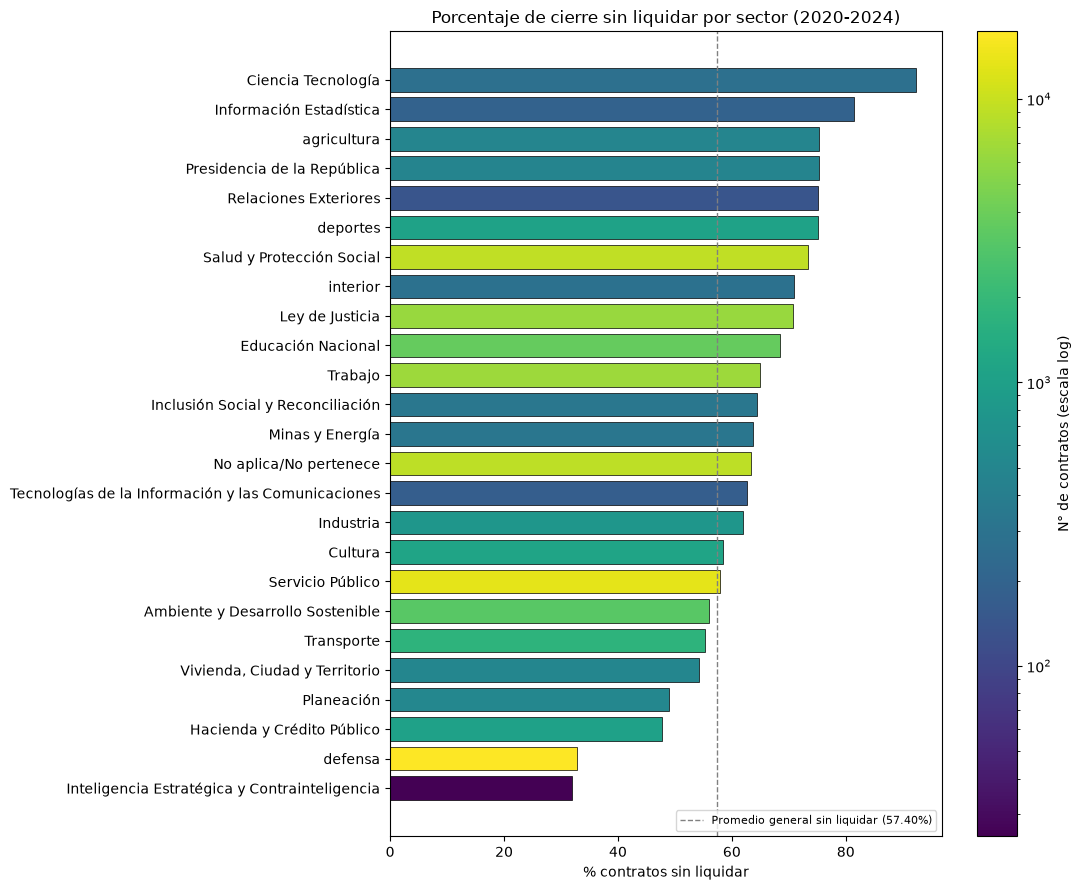

                                                    n_contratos  \
sector                                                            
Ciencia Tecnología                                          272   
Información Estadística                                     189   
agricultura                                                 491   
Presidencia de la República                                 477   
Relaciones Exteriores                                       141   
deportes                                                   1078   
Salud y Protección Social                                  9286   
interior                                                    288   
Ley de Justicia                                            6265   
Educación Nacional                                         3679   
Trabajo                                                    6612   
Inclusión Social y Reconciliación                           334   
Minas y Energía                                             32

In [18]:
resumen_sector = df_cerrados.groupby('sector').agg(
    n_contratos=('sector', 'size')
)
resumen_sector['pct_sin_liquidar'] = tabla_sector[1] / (tabla_sector[0] + tabla_sector[1]) * 100
resumen_sector = resumen_sector.sort_values('pct_sin_liquidar', ascending=True)

fig, ax = plt.subplots(figsize=(11, 9))

norm = plt.matplotlib.colors.LogNorm(vmin=resumen_sector['n_contratos'].min(), vmax=resumen_sector['n_contratos'].max())
colores = plt.cm.viridis(norm(resumen_sector['n_contratos']))

barras = ax.barh(resumen_sector.index, resumen_sector['pct_sin_liquidar'], color=colores, edgecolor='black', linewidth=0.5)

ax.axvline(tasa_sin_liquidar_general, color='gray', linestyle='--', linewidth=1,
           label=f'Promedio general sin liquidar ({tasa_sin_liquidar_general:.2f}%)')
ax.set_xlabel('% contratos sin liquidar')
ax.set_title('Porcentaje de cierre sin liquidar por sector (2020-2024)')
ax.legend(loc='lower right', fontsize=8)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('N° de contratos (escala log)')

plt.tight_layout()
plt.show()

print(resumen_sector.sort_values('pct_sin_liquidar', ascending=False).round(2))

**Interpretación.**

El gráfico deja claro que el riesgo de cierre sin liquidar por sector no está relacionado con el volumen de contratos. `Salud y Protección Social` (9286 contratos, 73.36%), `Ley de Justicia` (6265, 70.73%) y `Educación Nacional` (3679, 68.42%) se ubican claramente por encima del promedio general (57.40%) y combinan una tasa alta con una muestra grande.

`defensa`, el sector de mayor volumen entre los contratos cerrados o terminados (17335 contratos), se ubica muy por debajo del promedio (32.87%), junto a `Inteligencia Estratégica y Contrainteligencia` (32.00%, aunque con apenas 25 contratos). `Servicio Público`, el segundo en volumen (13138 contratos), queda muy cerca de la línea de referencia (57.97%).

Los porcentajes más altos del gráfico, `Ciencia Tecnología` (92.28%) e `Información Estadística` (81.48%), corresponden a sectores de volumen bajo (272 y 189 contratos). Aunque llamativos, deben interpretarse con más cautela.

Antes de convertir estos sectores en criterios, hay que revisar si se solapan con los factores de modalidad ya encontrados, lo que se hace en 3.12.

### 3.11 ¿El tipo de entidad se asocia con el cierre sin liquidar?

El enunciado menciona el tipo de entidad como una de las características que pueden asociarse con las desviaciones. El dataset lo describe con dos atributos, `orden` (Nacional, Territorial o Corporación Autónoma) y `entidad_centralizada` (Centralizada o Descentralizada), y se prueban ambos contra `sin_liquidar`.

**Paso 0. Umbral de relevancia práctica.** Se considera relevante una diferencia de al menos 10 puntos porcentuales entre grupos.

**Paso 1. Hipótesis.**
H0: la proporción de contratos sin liquidar es independiente del tipo de entidad.
H1: la proporción depende del tipo de entidad.

In [19]:
for columna in ['orden', 'entidad_centralizada']:
    tabla_entidad = pd.crosstab(df_cerrados[columna], df_cerrados['sin_liquidar'])
    resumen_entidad = pd.DataFrame({
        'n_contratos': tabla_entidad.sum(axis=1),
        'pct_sin_liquidar': (tabla_entidad[1] / tabla_entidad.sum(axis=1) * 100).round(2),
    })
    chi2_e, p_e, dof_e, esperadas_e = stats.chi2_contingency(tabla_entidad)
    cramers_v_e = (chi2_e / (tabla_entidad.values.sum() * (min(tabla_entidad.shape) - 1))) ** 0.5

    print(resumen_entidad)
    print(f'Chi2 = {chi2_e:.2f}, p = {p_e:.3g}, grados de libertad = {dof_e}')
    print(f'Minima frecuencia esperada: {esperadas_e.min():.2f}')
    print(f'Cramér V: {cramers_v_e:.4f}')
    print()

                      n_contratos  pct_sin_liquidar
orden                                              
Corporación Autónoma         1047             50.91
Nacional                    41194             52.07
Territorial                 35687             63.74
Chi2 = 1084.16, p = 3.79e-236, grados de libertad = 2
Minima frecuencia esperada: 446.03
Cramér V: 0.1180

                      n_contratos  pct_sin_liquidar
entidad_centralizada                               
Centralizada                60269             56.44
Descentralizada             17659             60.67
Chi2 = 99.48, p = 1.98e-23, grados de libertad = 1
Minima frecuencia esperada: 7522.89
Cramér V: 0.0357



**Interpretación.**

Las dos pruebas son estadísticamente significativas, pero solo una es relevante en la práctica.

Para `orden` (`chi2` = 1084.16, `df` = 2, p menor a 0.001, frecuencia esperada mínima de 446.03), las entidades territoriales tienen 63.74% de contratos sin liquidar frente a 52.07% en las nacionales, una diferencia de 11.67 puntos que supera el umbral de 10. El Cramér's V es 0.1180, un efecto pequeño. Las Corporaciones Autónomas (50.91%, 1047 contratos) se comportan como las nacionales.

Para `entidad_centralizada` (`chi2` = 99.48, `df` = 1, p menor a 0.001), la diferencia entre descentralizadas (60.67%) y centralizadas (56.44%) es de solo 4.23 puntos y el Cramér's V es 0.0357, un efecto despreciable. Es un resultado estadísticamente significativo solo por el tamaño de la muestra, y no se considera un criterio útil.

En conclusión, el nivel territorial de la entidad sí es un criterio de focalización relevante. Como este factor puede solaparse con el sector (por ejemplo, los hospitales públicos son en su mayoría entidades territoriales), no se interpreta como un efecto independiente del sector.

### 3.12 ¿Salud y régimen especial son el mismo foco?

Tanto el sector `Salud y Protección Social` (3.9) como las modalidades de régimen especial (3.3) aparecen como focos de cierre sin liquidar. Si la mayoría de los contratos de Salud se firman por régimen especial, recomendar ambos como criterios separados sería contar dos veces el mismo riesgo. Para comprobarlo se estratifica, se compara el efecto del régimen especial dentro de cada grupo de sector y el efecto de Salud dentro de cada grupo de modalidad, con el mismo umbral de 10 puntos porcentuales.

El mapa de calor posterior extiende este cruce a los 8 sectores de mayor volumen y todas las modalidades, ocultando las combinaciones con menos de 30 contratos.

In [20]:
df_cerrados['grupo_sector'] = np.where(df_cerrados['sector'] == 'Salud y Protección Social',
                                       'Salud y Protección Social', 'Otros sectores')
df_cerrados['grupo_modalidad'] = np.where(df_cerrados['modalidad_de_contratacion'].str.contains('régimen especial'),
                                          'Régimen especial', 'Otras modalidades')

print('Composición de cada grupo de sector por modalidad (%)')
print((pd.crosstab(df_cerrados['grupo_sector'], df_cerrados['grupo_modalidad'], normalize='index') * 100).round(2))
print()

tasa_estratos = df_cerrados.pivot_table(index='grupo_sector', columns='grupo_modalidad', values='sin_liquidar', aggfunc='mean') * 100
conteo_estratos = df_cerrados.pivot_table(index='grupo_sector', columns='grupo_modalidad', values='sin_liquidar', aggfunc='size')
print('% sin liquidar por estrato')
print(tasa_estratos.round(2))
print()
print('Número de contratos por estrato')
print(conteo_estratos)
print()

for grupo, datos in df_cerrados.groupby('grupo_sector'):
    tabla = pd.crosstab(datos['grupo_modalidad'], datos['sin_liquidar'])
    chi2_e, p_e, _, _ = stats.chi2_contingency(tabla)
    print(f'Dentro de {grupo}, régimen especial vs otras modalidades: p = {p_e:.3g}, Cramér V = {(chi2_e / tabla.values.sum()) ** 0.5:.4f}')

for grupo, datos in df_cerrados.groupby('grupo_modalidad'):
    tabla = pd.crosstab(datos['grupo_sector'], datos['sin_liquidar'])
    chi2_e, p_e, _, _ = stats.chi2_contingency(tabla)
    print(f'Dentro de {grupo}, Salud vs otros sectores: p = {p_e:.3g}, Cramér V = {(chi2_e / tabla.values.sum()) ** 0.5:.4f}')

salud_regimen = df_cerrados[(df_cerrados['grupo_sector'] == 'Salud y Protección Social') &
                            (df_cerrados['grupo_modalidad'] == 'Régimen especial')]
es_hospital = salud_regimen['nombre_entidad'].str.contains(r'E\.?S\.?E|HOSPITAL|SUBRED|EMPRESA SOCIAL DEL ESTADO', case=False)
print()
print(f'Contratos de Salud en régimen especial firmados por hospitales o E.S.E.: {es_hospital.mean() * 100:.2f}%')

Composición de cada grupo de sector por modalidad (%)


grupo_modalidad            Otras modalidades  Régimen especial
grupo_sector                                                  
Otros sectores                         95.31              4.69
Salud y Protección Social              30.90             69.10

% sin liquidar por estrato
grupo_modalidad            Otras modalidades  Régimen especial
grupo_sector                                                  
Otros sectores                         54.43             71.66
Salud y Protección Social              64.48             77.33

Número de contratos por estrato
grupo_modalidad            Otras modalidades  Régimen especial
grupo_sector                                                  
Otros sectores                         65424              3218
Salud y Protección Social               2869              6417



Dentro de Otros sectores, régimen especial vs otras modalidades: p = 6.78e-82, Cramér V = 0.0732
Dentro de Salud y Protección Social, régimen especial vs otras modalidades: p = 3.94e-38, Cramér V = 0.1340


Dentro de Otras modalidades, Salud vs otros sectores: p = 4.18e-26, Cramér V = 0.0404
Dentro de Régimen especial, Salud vs otros sectores: p = 1.29e-09, Cramér V = 0.0618

Contratos de Salud en régimen especial firmados por hospitales o E.S.E.: 99.45%


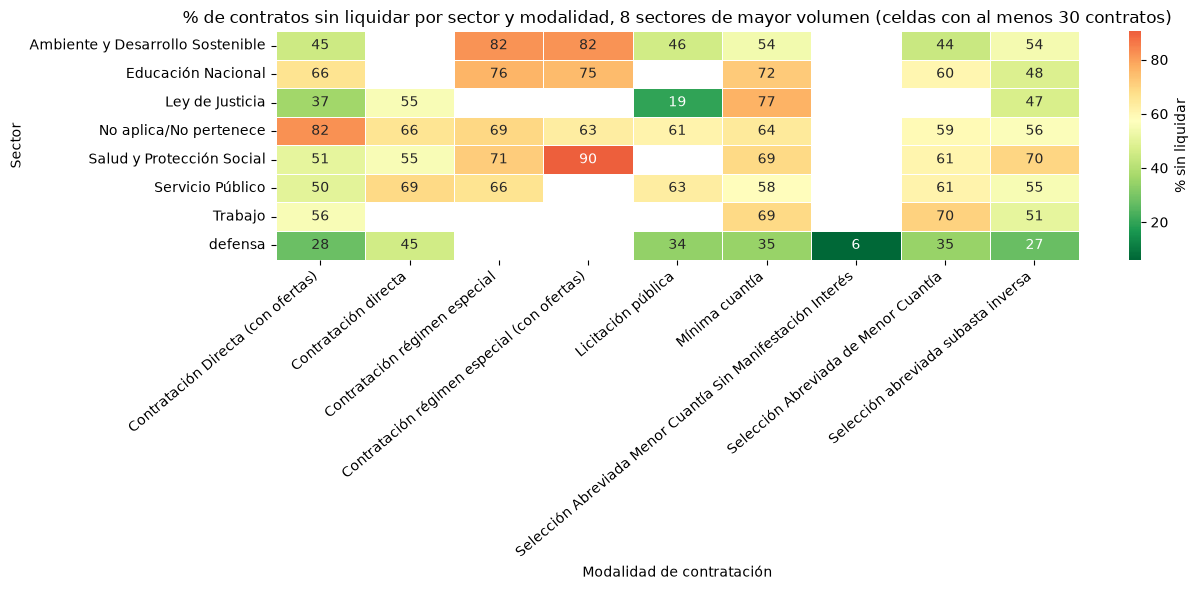

In [21]:
sectores_top = df_cerrados['sector'].value_counts().head(8).index
datos_mapa = df_cerrados[df_cerrados['sector'].isin(sectores_top)]

tasa_mapa = datos_mapa.pivot_table(index='sector', columns='modalidad_de_contratacion', values='sin_liquidar', aggfunc='mean') * 100
conteo_mapa = datos_mapa.pivot_table(index='sector', columns='modalidad_de_contratacion', values='sin_liquidar', aggfunc='size')
tasa_mapa = tasa_mapa.where(conteo_mapa >= 30)

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(tasa_mapa, annot=True, fmt='.0f', cmap='RdYlGn_r', center=tasa_sin_liquidar_general,
            cbar_kws={'label': '% sin liquidar'}, linewidths=0.5, ax=ax)
ax.set_title('% de contratos sin liquidar por sector y modalidad, 8 sectores de mayor volumen (celdas con al menos 30 contratos)')
ax.set_xlabel('Modalidad de contratación')
ax.set_ylabel('Sector')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

**Interpretación.**

El 69.10% de los contratos cerrados o terminados de Salud se firmó por régimen especial, frente a solo 4.69% en los demás sectores, y el 99.45% de esos contratos corresponde a hospitales y Empresas Sociales del Estado. Salud y régimen especial se solapan en buena parte.

Al estratificar, el régimen especial mantiene su efecto en los dos grupos. Fuera de Salud sube la tasa sin liquidar de 54.43% a 71.66% (17.23 puntos) y dentro de Salud de 64.48% a 77.33% (12.85 puntos), ambos por encima del umbral. En cambio, el efecto de Salud se reduce mucho al controlar por modalidad. Dentro del régimen especial, Salud solo suma 5.67 puntos (77.33% frente a 71.66%, Cramér's V = 0.0618), por debajo del umbral, y fuera del régimen especial la diferencia es de 10.05 puntos (64.48% frente a 54.43%), justo en el límite.

El mapa de calor confirma el patrón en otros sectores. El régimen especial tiene tasas altas en todos los sectores donde hay suficientes contratos, cerca de 82% en Ambiente y Desarrollo Sostenible, 75% a 76% en Educación Nacional y 71% a 90% en Salud. También muestra que el riesgo de `Ley de Justicia` se concentra en Mínima cuantía (cerca de 77%), mientras que sus contratos por Licitación pública tienen una tasa baja (cerca de 19%). `defensa` tiene tasas bajas en todas las modalidades.

En conclusión, el foco real es el régimen especial, no el sector Salud por sí mismo. Recomendar ambos como criterios separados duplicaría el esfuerzo de supervisión sobre los mismos hospitales. `Ley de Justicia`, en cambio, es un foco independiente de la modalidad, porque casi no usa régimen especial.

### 3.13 Síntesis: hacia un criterio compuesto de focalización

Al incorporar los cinco factores analizados (modalidad de contratación, valor del contrato, destino del gasto, sector y tipo de entidad), el hallazgo más importante es que `sector` es el predictor individual más fuerte de cierre sin liquidar (Cramér's V = 0.2939), seguido de la modalidad frente a no ejecución (0.2066), el destino del gasto frente a no ejecución (0.1602) y el orden de la entidad frente a cierre sin liquidar (0.1180).

- Las dos modalidades de **régimen especial** son el foco transversal: destacan en no ejecución y en cierre sin liquidar, y su efecto se sostiene dentro y fuera del sector Salud.
- **Ley de Justicia** y **Educación Nacional** son focos sectoriales de alto volumen y alta tasa de cierre sin liquidar. El exceso de **Salud y Protección Social** se explica en buena parte por el régimen especial de sus hospitales.
- Las **entidades territoriales** tienen 11.67 puntos más de contratos sin liquidar que las nacionales.
- Los contratos de **Funcionamiento** tienen 16.23 puntos más de no ejecución que los de Inversión.
- **Licitación pública** es el foco de adiciones de plazo por frecuencia (23.71% de contratos adicionados), no por la magnitud en días, y dentro de ella los contratos más costosos son los que más quedan sin liquidar.
- **valor_del_contrato**, usado solo, no alcanzó el umbral de relevancia (29.63% frente a 30%), y **entidad_centralizada** tuvo un efecto despreciable (Cramér's V = 0.0357).

Salvo el cruce de Salud con régimen especial (3.12) y el valor dentro de cada modalidad (3.6), los factores se probaron de forma independiente, sin un modelo multivariado. Esto se documenta como limitación en el Punto 4.

## 4. Generación de resultados

### 4.1 Contexto y objetivo

Esta sección resume los resultados del análisis realizado sobre 139853 contratos de bienes y suministros firmados entre 2020 y 2024 y registrados en SECOP II, el periodo que se justificó en el notebook 01 a partir de los 196391 contratos del dataset original. El objetivo es proponer criterios de focalización de supervisión basados en evidencia estadística, evaluando cinco factores conocidos desde la firma del contrato, la modalidad de contratación, el valor del contrato, el destino del gasto, el sector y el tipo de entidad, frente a tres señales de desviación, adición de plazo, presupuesto no ejecutado y cierre sin liquidar.

### 4.2 Hallazgos generales

En el periodo 2020-2024, el 7.90% de los contratos tuvo adición de plazo, el 42.54% de los contratos cerrados o terminados no tiene ningún pago registrado, y el 57.40% de los contratos cerrados o terminados quedó sin liquidar.

`Sector` resultó ser el predictor más fuerte (Cramér's V de 0.2939 frente a cierre sin liquidar), seguido de `modalidad_de_contratacion` (0.2066 frente a no ejecución y 0.1728 frente a cierre sin liquidar), `destino_gasto` (0.1602 frente a no ejecución) y `orden` de la entidad (0.1180 frente a cierre sin liquidar). `valor_del_contrato`, evaluado de forma independiente, resultó ser un predictor débil (correlación rank-biserial de -0.1480), y `entidad_centralizada` tuvo un efecto despreciable (0.0357).

### 4.3 Criterios de focalización propuestos

Todos los criterios se basan en atributos conocidos desde la firma del contrato, así que se pueden aplicar desde ese momento.

**1. Modalidades de régimen especial, foco transversal.** `Contratación régimen especial (con ofertas)` tiene la tasa más alta de no ejecución (82.97%) y de cierre sin liquidar (83.94%), y `Contratación régimen especial` también supera el promedio en ambas (60.33% y 72.16%). El efecto se mantiene dentro y fuera del sector Salud y en todos los sectores con suficientes contratos. Este criterio cubre, además, el 69.10% de los contratos de Salud, firmados casi en su totalidad por hospitales y Empresas Sociales del Estado.

**2. Sectores Ley de Justicia y Educación Nacional.** `Ley de Justicia` (6265 contratos, 70.73% sin liquidar) y `Educación Nacional` (3679 contratos, 68.42%) combinan una tasa más de 10 puntos por encima del promedio general (57.40%) con un volumen alto. En `Ley de Justicia` el riesgo se concentra en sus contratos de Mínima cuantía. `Salud y Protección Social` (73.36%) no se recomienda como criterio aparte, porque su exceso se explica en buena parte por el régimen especial (criterio 1).

**3. Entidades territoriales.** Las entidades de orden territorial tienen 63.74% de contratos sin liquidar frente a 52.07% en las nacionales, 11.67 puntos más.

**4. Destino del gasto de funcionamiento.** El 48.88% de los contratos de funcionamiento cerrados o terminados no tiene pagos registrados, frente a 32.65% en inversión. Como parte de esta señal puede ser falta de registro, la supervisión debería empezar por confirmar con la entidad si el pago ocurrió.

**5. Licitación pública, foco de plazos y de alto valor.** El 23.71% de sus contratos recibió adición de plazo, frente a 6.13% en Mínima cuantía, aunque las adiciones son cortas frente a su plazo (mediana de 11.65%), así que su supervisión debería centrarse en el cronograma. Además, es la única modalidad donde los contratos sin liquidar son los de mayor valor, por lo que dentro de ella conviene priorizar los contratos más costosos.

**El valor del contrato como filtro secundario.** Usado solo no alcanzó el umbral de relevancia (29.63% frente a 30%), y su relación con el riesgo cambia según la modalidad. Debería usarse como filtro dentro de Licitación pública, no como criterio independiente.

**No priorizar por volumen.** `Mínima cuantía` concentra el 59% de los contratos del periodo pero sus tasas están cerca del promedio. `defensa`, el sector de mayor volumen entre los contratos cerrados o terminados, tiene la tasa sin liquidar más baja de los sectores grandes (32.87%), y `Servicio Público`, el segundo, está en el promedio (57.97%). Priorizarlos solo por su tamaño sería ineficiente.

### 4.4 Limitaciones del análisis

**Factores probados por separado.** Salvo el cruce de Salud con régimen especial y el valor dentro de cada modalidad, los factores se probaron de forma independiente frente a cada señal, sin un modelo multivariado (como una regresión logística) que controle por todos al mismo tiempo. Parte de la asociación de un factor puede explicarse por otro, por ejemplo el orden territorial y el sector.

**Significancia con muestras grandes.** Con 139853 contratos casi cualquier diferencia resulta estadísticamente significativa, por eso las conclusiones se basaron en umbrales de relevancia práctica definidos antes de cada prueba y en el tamaño del efecto. La prueba de sector cumplió el supuesto de frecuencia esperada mínima de forma ajustada (10.65), porque algunos sectores tienen muestras pequeñas. Solo las 9 pruebas de valor dentro de cada modalidad se corrigieron por comparaciones múltiples.

**La no ejecución puede ser falta de registro.** El 15.75% de las entidades con al menos 5 contratos cerrados no registra ningún pago en SECOP II, y aporta el 20.61% de los contratos marcados como no ejecutados. Además, el porcentaje de contratos sin pago registrado bajó de 64.02% en 2020 a 47.14% en 2024 (notebook 01), señal de que el registro de pagos fue mejorando. `no_ejecutado` debe leerse como falta de trazabilidad financiera, no necesariamente como falta de pago.

**La liquidación no siempre es obligatoria.** Las entidades de régimen especial, como las Empresas Sociales del Estado, contratan bajo normas de derecho privado y la obligación de liquidar depende de su propio manual de contratación. Parte del cierre sin liquidar en el régimen especial podría no ser una desviación sino una práctica permitida, algo que la oficina de control interno debería validar antes de aplicar el criterio 1.

**Composición cambiante dentro del periodo.** La participación del régimen especial pasó de 6.75% en 2020 a 18.93% en 2023, por la entrada de nuevas entidades a SECOP II más que por un cambio en cómo contratan. Los años del periodo no tienen exactamente la misma mezcla de entidades.

**Periodo y causalidad.** Los resultados aplican a contratos firmados entre 2020 y 2024. Se excluyeron 2019, por su forma distinta de registro, y 2025, por tener el ciclo de vida incompleto. Finalmente, el análisis identifica asociaciones, no relaciones causales, y los criterios deberían validarse con conocimiento del proceso administrativo real antes de implementarse.